# Extract data from NAMD simulation log file

In [1]:
#Import libraries
import sys,os
import numpy as np
import matplotlib.pyplot as plt

### Extract Pot_Energy, T and pressure data from a NAMD log file

In [5]:
#input log file
file1= "MDequil.log"
print(file1)

MDequil.log


**Write data in two output files**

In [6]:
g_ = open(file1.split('.log')[0] + '_output.dat','a') #generic unformatted output

**Extract Energy data in unformated file**

In [7]:
#Init counter
count_T = 0

#Read data from LOG file and save relevant data to generic unformatted output
with open(file1,'r') as f_:
    for line in f_:
        if line[0:6] == "ETITLE":
           count_T += 1
           if count_T == 1:
              g_.write(line)
        if line[0:6] == "ENERGY":
              g_.write(line)
g_.close()

**Save the data in a formated file in 5 columns: Time step, Etotal, Epotential, T, p **

In [8]:
#Create a new file for TS, Pot. Energy, Temp, p, Volume 
file2= open(file1.split('.log')[0] + '_ETpV.dat', 'w')
file2.write(f'# step Epot T p V \n')

#read the data from file1 output (all data in columns)
d= np.genfromtxt(file1.split('.log')[0] + '_output.dat',skip_header=1,usecols=(1,12,13,16,18))

ts=d[:,0]  # time steps
temp=d[:,1] # T
Epot=d[:,2] # Epot
press=d[:,3] # p
Vol=d[:,4] # V

#Save the selected data in file2
num_steps=ts.size  #number of time steps in the simulation
for i in range(num_steps):
   file2.write(f'{int(ts[i])} {Epot[i]} {temp[i]} {press[i]} {Vol[i]} \n') #save TS, Epotential, T, p, V
file2.close()

**Plot the data**

Plot Potential Energy, Temp, p, Volume as a funciton of time in ps (**check your value of dt**)

In [9]:
#Put here your time step to convert steps to real time
dt =2 #fs
time=(dt/1000)*ts #ps

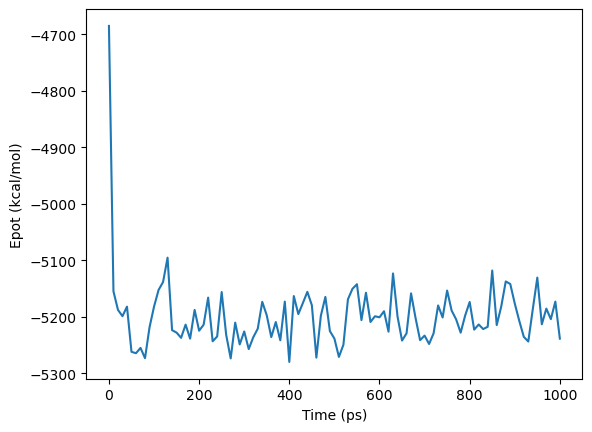

In [10]:
plt.ylabel('Epot (kcal/mol)')
plt.xlabel('Time (ps)')
plt.plot(time,Epot)
plt.show()

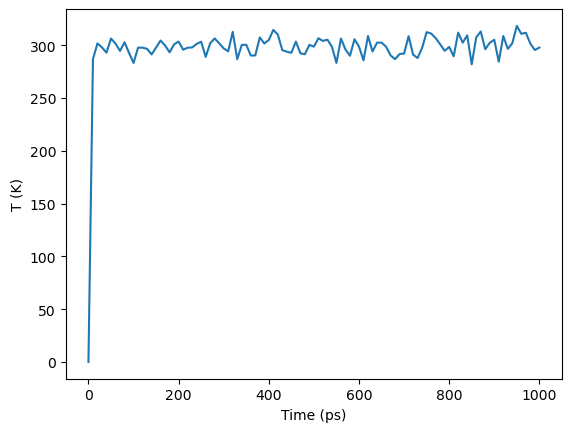

In [11]:
plt.ylabel('T (K)')
plt.xlabel('Time (ps)')
plt.plot(time,temp)
plt.show()

In [12]:
#Average T (excluding initial data)
N_exclude=10
Tav=sum(temp[10:])/len(temp[10:])
print(Tav)

299.4121175824176


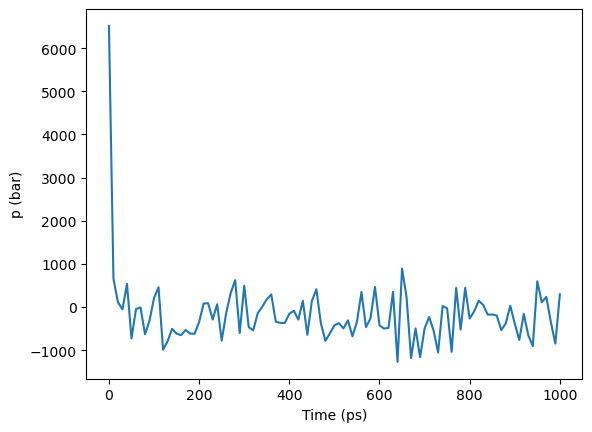

In [13]:
plt.ylabel('p (bar)')
plt.xlabel('Time (ps)')
plt.plot(time,press)
plt.show()

In [14]:
#Average p (excluding initial data)
N_exclude=10
pav=sum(press[10:])/len(press[10:])
print(pav)

-253.25076373626376


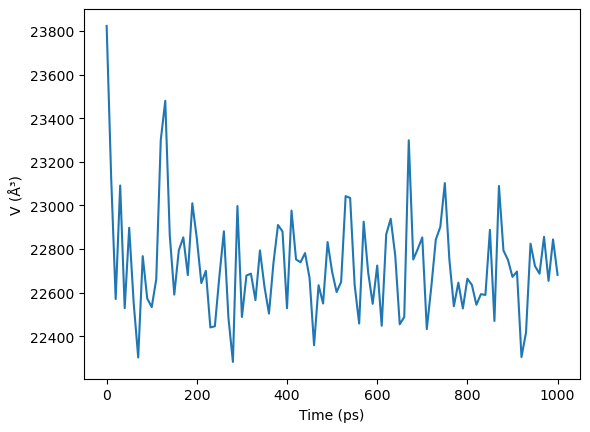

In [15]:
plt.ylabel('V (Å³)')
plt.xlabel('Time (ps)')
plt.plot(time,Vol)
plt.show()

In [16]:
#Average Vol (excluding initial data)
N_exclude=10
Vav=sum(Vol[10:])/len(Vol[10:])
print(Vav)

22717.31168351648
